## 03 - Dimensionality Reduction & Clustering  
Mục tiêu: Giảm chiều bằng PCA, UMAP, sau đó phân cụm bằng k-means

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

feat = pd.read_parquet('data/order_features.parquet')
X_scaled = np.load('data/X_scaled.npy')
with open('data/feature_cols.json') as f:
    cols = json.load(f)
dept_cols = cols['dept_cols']
cluster_feature_cols = cols['cluster_feature_cols']

print(feat.shape, X_scaled.shape)

(103761, 41) (103761, 29)


# 1. PCA

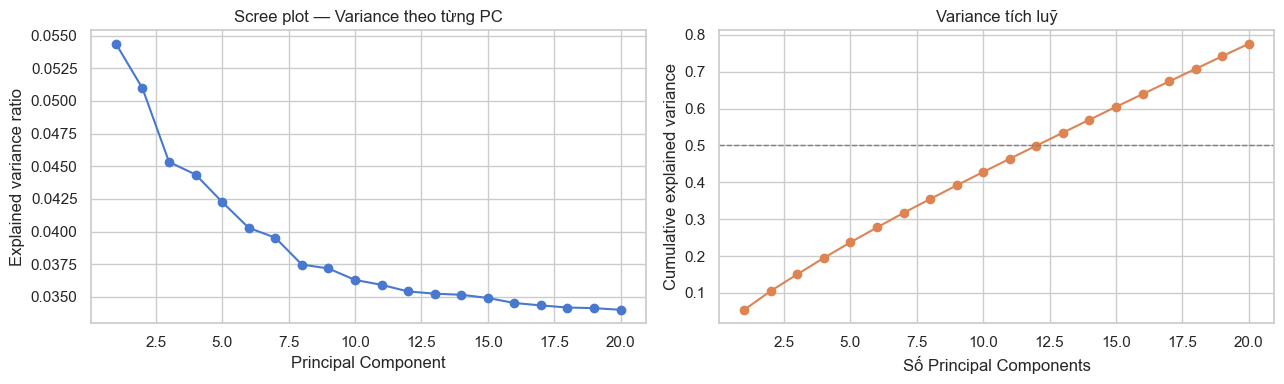

12 PC đầu giải thích 49.9% phương sai


In [17]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=20, random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, 21), pca_full.explained_variance_ratio_, marker='o')
axes[0].set_title('Scree plot — Variance theo từng PC')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(range(1, 21), cum_var, marker='o', color='#DD8452')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Variance tích luỹ')
axes[1].set_xlabel('Số Principal Components'); axes[1].set_ylabel('Cumulative explained variance')
plt.tight_layout()
plt.show()

print(f'12 PC đầu giải thích {cum_var[11]*100:.1f}% phương sai')

**Nhận xét**: phương sai giải thích tăng khá đều

In [18]:
pca = PCA(n_components=12, random_state=42).fit(X_scaled)
X_pca = pca.transform(X_scaled)
print('X_pca shape:', X_pca.shape)

X_pca shape: (103761, 12)


1.1 Loading của PC1 và PC2 - thành phần nào chi phối các trục chính

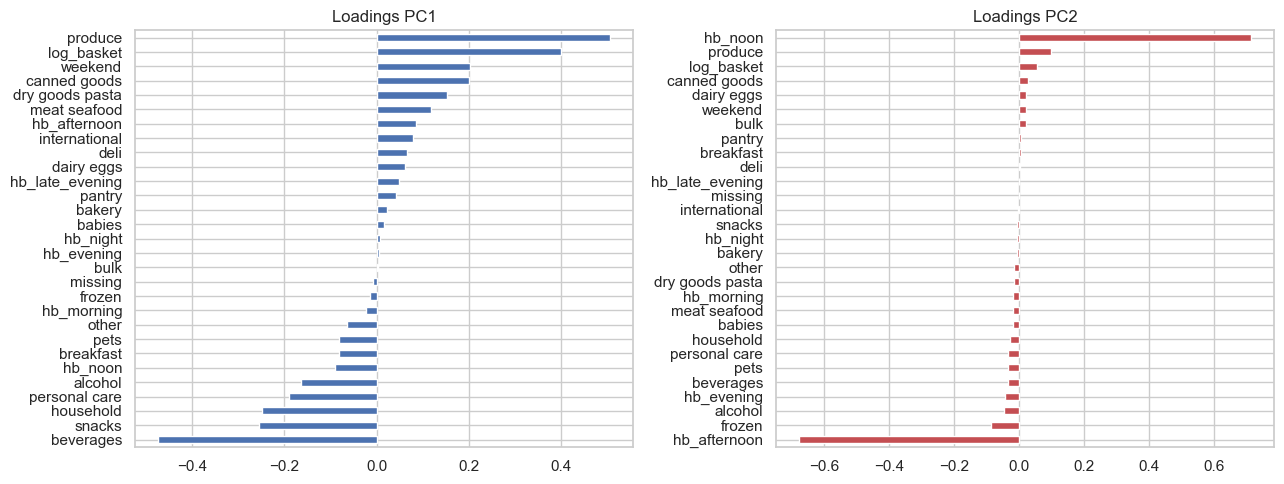

In [19]:
loadings = pd.DataFrame(pca.components_[:2].T, index=cluster_feature_cols, columns=['PC1', 'PC2'])
fig, axes = plt.subplots(1, 2, figsize=(13,5))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Loadings PC1')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Loadings PC2')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_embedded = pca.fit_transform(X_scaled)

# 3 chọn số cụm K

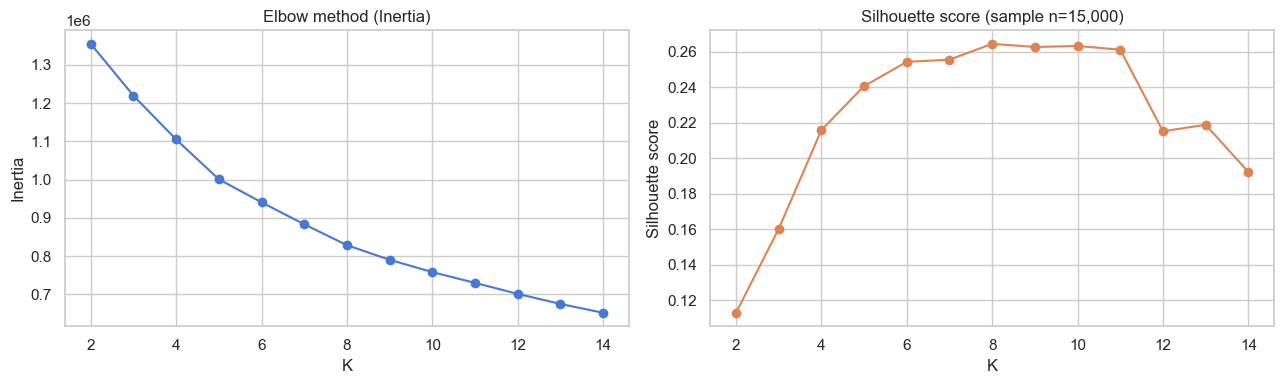

K=2: silhouette=0.1130
K=3: silhouette=0.1603
K=4: silhouette=0.2159
K=5: silhouette=0.2407
K=6: silhouette=0.2543
K=7: silhouette=0.2556
K=8: silhouette=0.2645
K=9: silhouette=0.2627
K=10: silhouette=0.2633
K=11: silhouette=0.2612
K=12: silhouette=0.2153
K=13: silhouette=0.2189
K=14: silhouette=0.1923


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 15)
inertias, sils = [], []
sample_idx = np.random.RandomState(42).choice(len(X_pca), 15000, replace=False)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_title('Elbow method (Inertia)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(ks), sils, marker='o', color='#DD8452')
axes[1].set_title('Silhouette score (sample n=15,000)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

for k, s in zip(ks, sils):
    print(f'K={k}: silhouette={s:.4f}')

In [22]:
K = 8
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_pca)
feat['cluster'] = kmeans.labels_
print(feat['cluster'].value_counts().sort_index())
print('Silhouette (full, sample 15k):', round(silhouette_score(X_pca[sample_idx], kmeans.labels_[sample_idx]), 4))

cluster
0    15532
1     3466
2    29534
3     3165
4    14401
5     1867
6    30780
7     5016
Name: count, dtype: int64
Silhouette (full, sample 15k): 0.2645


In [24]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

palette = sns.color_palette("tab10", K)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---------------- PCA ----------------
for c in range(K):
    mask = feat['cluster'] == c
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=5,
        alpha=0.4,
        color=palette[c],
        label=f'Cluster {c}'
    )

axes[0].set_title('PCA Projection (KMeans, K=8)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# ---------------- t-SNE ----------------
for c in range(K):
    mask = feat['cluster'] == c
    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=5,
        alpha=0.4,
        color=palette[c],
        label=f'Cluster {c}'
    )

axes[1].set_title('t-SNE Projection (KMeans, K=8)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# Chỉ hiện legend một lần
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right')

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

KeyboardInterrupt: 